In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Suppress warnings
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [3]:

import os
import time
import warnings
from datetime import datetime, date
from pathlib import Path

import gymnasium as gym
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from gymnasium import spaces
from IPython.display import clear_output
from scipy.special import erfc
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from tqdm import tqdm


In [4]:
note='0630_ablation_vonly'
modelnoise=0.3
modelvcost=0.1
modelwcost=0
modeltimecost=0

In [5]:
smallgap=6
largegap=13


# small
info_matrix_small=np.load(f'new_info_matrix_hres_{smallgap}.npy')[:,:-10]
# mask (mimic animal cannot see well)
mask = np.ones_like(info_matrix_small)
# Create a vertical gradient (1.0 at top, decreasing to 0.3 at bottom)
gradient = np.linspace(0.0, 1., info_matrix_small.shape[1])
for i in range(info_matrix_small.shape[1]):
    mask[:, i] = gradient[i]
# Apply the mask to darken the bottom gradually
masked_info_matrix_small = info_matrix_small * mask


# large
info_matrix_large=np.load(f'new_info_matrix_hres_{largegap}.npy')[:,:-10]
# mask (mimic animal cannot see well)
mask = np.ones_like(info_matrix_large)
# Create a vertical gradient (1.0 at top, decreasing to 0.3 at bottom)
gradient = np.linspace(0.0, 1., info_matrix_large.shape[1])
for i in range(info_matrix_large.shape[1]):
    mask[:, i] = gradient[i]
# Apply the mask to darken the bottom gradually
masked_info_matrix_large = info_matrix_large * mask


In [6]:

class MouseNavigationEnv(gym.Env):
    """
    Mouse Navigation Environment with Left and Right Visual Areas.

    The mouse navigates a 2D arena to find the correct reward port based on
    accumulated left and right visual information, affected by observation noise.
    """

    def __init__(self, noise, info_matrix, nx=60, ny=50, max_v=4, i_threshold=20,
                 vcost=0.01, wcost=0.01, timecost=0.01, info_scale=1 / 20,
                 max_steps=100, reward_magnitude=1):
        super(MouseNavigationEnv, self).__init__()

        # Arena dimensions
        self.nx = nx
        self.ny = ny
        self.max_v = max_v
        self.i_threshold = i_threshold

        # Observation noise (standard deviation)
        self.noise = noise

        # Costs
        self.vcost = vcost
        self.wcost = wcost
        self.timecost = timecost
        self.info_scale = info_scale
        self.reward_magnitude = reward_magnitude

        self.info_matrix = info_matrix

        # Port locations
        self.left_port_x = 0
        self.right_port_x = nx - 1
        self.port_y = ny - 1

        # Correct port will be randomly selected in reset()
        self.correct_port_x = None

        # Maximum steps per episode
        self.max_steps = max_steps

        # Action space: Acceleration in x and y directions [-3, -2, -1, 0, 1, 2, 3]
        self.action_space = spaces.MultiDiscrete([7, 7])

        # Observation space: [x, y, vx, vy, left_info, right_info]
        self.observation_space = spaces.Box(
            low=np.array([0, 0, -1, -1, -1]),
            high=np.array([1, 1, 1, 1, 1]), # normalize
            # high=np.array([nx - 1, ny - 1, max_v, max_v, 1]),
            dtype=np.float32
        )

        # Initialize state
        self.reset()

    def reset(self, seed=None, options=None):
        """Reset the environment to the starting state."""
        super().reset(seed=seed)

        # Start at the bottom center
        self.x = self.nx // 2
        self.y = 0

        # Start with zero velocity
        self.vx = 0
        self.vy = 0

        # Reset accumulated information
        self.cumulative_info = 0

        # Reset step counter
        self.steps = 0

        if options is not None:
            self.correct_port_x = options
        else:
            # Randomly select the correct port (left or right)
            self.correct_port_x = np.random.choice([self.left_port_x, self.right_port_x])

        # Current state
        self._update_state()

        return self.state, {}

    def _update_state(self):
        """Update the state vector."""
        if self.correct_port_x == 0:
            rewardp=self._success_prob_from_info(self.cumulative_info)*2-1
        else:
            rewardp=(self._success_prob_from_info(-self.cumulative_info)*2-1)*-1
        self.state = np.array([
            self.x/(self.nx-1), 
            self.y/(self.ny-1), 
            self.vx/self.max_v, 
            self.vy/self.max_v,
            rewardp
        ], dtype=np.float32)

    def _get_area_info_at_position(self, x, y, testing=False):
        """Get left and right area information at the given position with noise."""
        # Convert to integer indices and clip to bounds
        x_idx = max(0, min(int(x), self.nx - 1))
        y_idx = max(0, min(int(y), self.ny - 1))

        # Get raw values from matrices
        raw = self.info_matrix[x_idx, y_idx] * self.info_scale

        # Add observation noise. the noisy can be no info at all, or can by no noise (full info at the location)
        # we want: less info more chance to not observe anyything
        # noisy = (raw - np.max(self.info_matrix)/3*self.noise*(np.random.uniform(0, 1)))
        p=raw/np.max(self.info_matrix)
        noisy=(p-np.random.uniform(0, 1*self.noise))
        noisy = max(0, noisy)

        if testing:
            noisy = raw
        if self.correct_port_x == 0:
            return noisy
        else:
            return -noisy

    def _success_prob_from_info(self, info_val):
        """
        Calculate success probability based on accumulated left and right information.
        Higher difference between the correct choice and incorrect choice
        leads to higher success probability.
        """

        info_val = abs(info_val)

        # Use the erfc function: (1/2) * erfc(-sqrt(J/2))
        return 0.5 * erfc(-np.sqrt(info_val / 2))

    def step(self, action, testing=False):
        """
        Take a step in the environment based on the action.

        Args:
            action: [ax, ay] representing accelerations in x and y directions
                   Each element is in range [0, 6] which maps to [-3, -2, -1, 0, 1, 2, 3]

        Returns:
            (state, reward, done, truncated, info)
        """
        reward=0

        # Increment step counter
        self.steps += 1

        # Map action to acceleration
        ax = action[0]-3
        ay = action[1]-3
        # print(ax,ay)
        # Calculate next velocity
        next_vx = self.vx + ax
        next_vy = self.vy + ay
        # print(next_vx,next_vy)
        # Check velocity constraints
        speed = np.sqrt(next_vx**2 + next_vy**2)
        if speed >= self.max_v:
            # Scale down the velocity to max_v
            scaling_factor = (self.max_v - 0.1) / speed
            next_vx = next_vx * scaling_factor
            next_vy = next_vy * scaling_factor

        # Store old position for reward calculation
        old_x, old_y = self.x, self.y

        # Update position
        self.x += next_vx
        self.y += next_vy

        # wall penalty
        wall_penalty = 0
        # original_x, original_y = self.x, self.y

        # Check if hitting walls and apply penalty
        if self.x < 0 or self.x >= self.nx:
            wall_penalty -= 0.01  # Adjust penalty amount as needed
        if self.y < 0 or self.y >= self.ny:
            wall_penalty -= 0.01
        reward += wall_penalty

        
        # Clip position to arena boundaries
        self.x = max(0, min(self.x, self.nx - 1))
        self.y = max(0, min(self.y, self.ny - 1))

        # Check if approaching a port and enforce horizontal approach
        approaching_port = (self.y >= self.port_y - abs(next_vy) and
                            (abs(self.x - self.left_port_x) <= abs(next_vx) or
                            abs(self.x - self.right_port_x) <= abs(next_vx)))

        if approaching_port:
            # Force horizontal approach by zeroing out vertical velocity
            self.vy = 0
        else:
            self.vy = next_vy

        self.vx = next_vx

        # Accumulate left and right information at current position
        info_gain = self._get_area_info_at_position(old_x, old_y, testing)
        self.cumulative_info += info_gain

        # Calculate costs
        velocity_cost = np.sqrt(self.vx**2 + self.vy**2) * self.vcost
        accel_cost = np.sqrt(ax**2 + ay**2) * self.wcost
        step_cost = -velocity_cost - accel_cost - self.timecost

        # Check if done
        at_left_port = (round(self.y) == self.port_y and round(self.x) == self.left_port_x)
        at_right_port = (round(self.y) == self.port_y and round(self.x) == self.right_port_x)
        at_port = at_left_port or at_right_port

        stopped = (abs(self.vx) < 0.01 and abs(self.vy) < 0.01 and self.steps > 1)
        reached_steps_limit = self.steps >= self.max_steps

        done = at_port or stopped or reached_steps_limit

        # Calculate reward
        reward += step_cost  # Always apply movement costs
        success_prob = self._success_prob_from_info(self.cumulative_info)
        if at_port:
            # Calculate success probability based on accumulated information
            

            # Check if the mouse chose the correct port
            correct_choice = ((at_left_port and self.correct_port_x == self.left_port_x) or
                              (at_right_port and self.correct_port_x == self.right_port_x))

            # Stochastically determine success based on accumulated information
            if correct_choice:
                # Success with probability based on accumulated info
                reward_outcome = success_prob * self.reward_magnitude
            else:
                # Failure with probability based on accumulated info (incorrect choice)
                # reward_outcome = 1 - success_prob*self.reward_magnitude
                reward_outcome = -success_prob * self.reward_magnitude*5

            reward += reward_outcome
        elif stopped:
            # Penalty for stopping without reaching a port
            reward -= 2.5 * self.reward_magnitude
        elif reached_steps_limit:
            # Small penalty for timeout
            reward -= 0.25 * self.reward_magnitude

        # if know which port, reward for going toward it
        # if success_prob>0.3:
        #     # print(success_prob, self.vx, np.sign(self.cumulative_info), success_prob*self.vx*np.sign(self.cumulative_info)*-1)
        #     away_punish=success_prob*self.vx*np.sign(self.cumulative_info)*-1*0.05
        #     reward+=min(0,away_punish)

        # Update state
        self._update_state()

        # Info dictionary for additional data
        info = {
            'position': (self.x, self.y),
            'velocity': (self.vx, self.vy),
            'cumulative_info': self.cumulative_info,
            'step_cost': step_cost,
            'at_port': at_port,
            'correct_port': 'left' if self.correct_port_x == self.left_port_x else 'right',
            'chosen_port': 'left' if at_left_port else ('right' if at_right_port else None),
            'success_prob': self._success_prob_from_info(
                self.cumulative_info
            ),
            'info_gain': info_gain,
        }

        return self.state, reward, done, False, info



In [7]:
# Create environment
env_small = MouseNavigationEnv(
    info_matrix=info_matrix_small,
    nx=60, ny=50, max_v=4, i_threshold=5, 
    noise=modelnoise, 
    vcost=modelvcost, 
    wcost=modelwcost, 
    timecost=modeltimecost, 
    info_scale=0.3,
    max_steps=200, 
    reward_magnitude=3
)
env_large= MouseNavigationEnv(
    info_matrix=info_matrix_large,
    nx=60, ny=50, max_v=4, i_threshold=5, 
    noise=modelnoise, 
    vcost=modelvcost, 
    wcost=modelwcost, 
    timecost=modeltimecost, 
    info_scale=0.3,
    max_steps=200, 
    reward_magnitude=3
)

model_small = PPO("MlpPolicy", env_small, verbose=0, 
            learning_rate=0.0001,
            n_steps=1024,
            batch_size=256, 
            gamma=0.99,
            ent_coef=0.05,  # Encourage exploration
            clip_range=0.2,
            # n_epochs=10,    # More updates per batch
            gae_lambda=0.95)

model_large = PPO("MlpPolicy", env_large, verbose=0, 
            learning_rate=0.0001,
            n_steps=1024,
            batch_size=256, 
            gamma=0.99,
            ent_coef=0.05,  # Encourage exploration
            clip_range=0.2,
            gae_lambda=0.95)

In [8]:
def compare_models_noise(model1, model2, env1, env2, info_matrix1, info_matrix2, 
                         trials_per_condition=30, model1_label="Model 1", model2_label="Model 2",
                         colors_choice=['#1f77b4', '#ff7f0e'], save_path=None, figure_title='Model Comparison - Average Trajectories'):
    """
    Compare two models on two different environments with trajectory visualization.
    
    Parameters:
    - model1, model2: The trained models to compare
    - env1, env2: The environments for each model
    - info_matrix1, info_matrix2: Information matrices for each environment
    - trials_per_condition: Number of trials to run for each condition (left/right)
    - model1_label, model2_label: Labels for the models in the legend
    - colors_choice: Colors for left/right trajectories
    - save_path: Optional path to save the figure
    """
    import warnings
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    
    # Function to interpolate trajectories (assuming this exists in your code)
    def interpolate_trajectory(x, y, n_points):
        """Interpolate trajectory to fixed number of points"""
        from scipy.interpolate import interp1d
        if len(x) < 2:
            return np.array([x[0]] * n_points), np.array([y[0]] * n_points)
        
        t_orig = np.linspace(0, 1, len(x))
        t_new = np.linspace(0, 1, n_points)
        
        fx = interp1d(t_orig, x, kind='linear')
        fy = interp1d(t_orig, y, kind='linear')
        
        return fx(t_new), fy(t_new)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(6, 5))
    
    # Process Model 1
    print(f"Running {model1_label} trials...")
    model1_data = run_model_trials(model1, env1, trials_per_condition)
    
    # Process Model 2  
    print(f"Running {model2_label} trials...")
    model2_data = run_model_trials(model2, env2, trials_per_condition)
    
    # Plot Model 1 trajectories
    plot_model_trajectories(model1_data, colors_choice, alpha=0.3, linewidth=0.8, 
                           linestyle='-', interpolate_trajectory=interpolate_trajectory)
    
    # Plot Model 2 trajectories
    plot_model_trajectories(model2_data, colors_choice, alpha=0.3, linewidth=0.8, 
                           linestyle='--', interpolate_trajectory=interpolate_trajectory)
    
    # Create legend
    handles, labels = plt.gca().get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    
    # Create dummy handles for model comparison
    line_model1 = Line2D([0], [0], color='black', linewidth=1.5, linestyle='-')
    line_model2 = Line2D([0], [0], color='black', linewidth=1.5, linestyle='--')
    
    # Combine legends
    combined_handles = list(unique.values()) + [line_model1, line_model2]
    combined_labels = list(unique.keys()) + [model1_label, model2_label]
    
    plt.legend(combined_handles, combined_labels)
    
    # Styling
    plt.xlabel('x position (cm)')
    plt.ylabel('y position (cm)')
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    plt.xticks([])
    plt.yticks([])
    
    # Add scale bar
    x0, y0 = -15, -5
    ax.plot([x0, x0 + 10], [y0, y0], color='black', lw=1.5)  # horizontal bar (10 cm)
    ax.plot([x0, x0], [y0, y0 + 5], color='black', lw=1.5)   # vertical bar (5 cm)
    
    # Add text labels
    ax.text(x0 + 5, y0 - 0.8, '10 cm', ha='center', va='top', fontsize=8)
    ax.text(x0 - 0.8, y0 + 2.5, '5 cm', ha='right', va='center', fontsize=8, rotation='vertical')
    
    ax.set_title(figure_title)
    
    # Save figure if path provided
    if save_path:
        plt.savefig(save_path, format='svg', bbox_inches='tight')
    
    plt.show()
    
    # Print summary statistics
    print_model_comparison_stats(model1_data, model2_data, model1_label, model2_label)


def run_model_trials(model, env, trials_per_condition):
    """Run trials for a single model and return trajectory data"""
    import warnings
    import numpy as np
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Storage for trial data
        left_trial_positions_x = []
        left_trial_positions_y = []
        left_trial_results = []
        left_trial_rewards = []
        
        right_trial_positions_x = []
        right_trial_positions_y = []
        right_trial_results = []
        right_trial_rewards = []
        
        # Run left port trials
        for trial in range(trials_per_condition):
            obs, _ = env.reset(options=0)
            done = False
            positions_x = []
            positions_y = []
            total_reward = 0
            
            while not done:
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, done, _, info = env.step(action)
                total_reward += reward
                
                positions_x.append(info['position'][0])
                positions_y.append(info['position'][1])
            
            positions_x = np.array(positions_x)
            positions_y = np.array(positions_y)
            
            left_trial_positions_x.append(positions_x)
            left_trial_positions_y.append(positions_y)
            left_trial_rewards.append(total_reward)
            
            result = "Success" if info['chosen_port'] == info['correct_port'] else "Failure"
            if info['chosen_port'] is None:
                result = "Timeout/Stopped"
            left_trial_results.append(result)
        
        # Run right port trials
        for trial in range(trials_per_condition):
            obs, _ = env.reset(options=59)
            done = False
            positions_x = []
            positions_y = []
            total_reward = 0
            
            while not done:
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, done, _, info = env.step(action)
                total_reward += reward
                
                positions_x.append(info['position'][0])
                positions_y.append(info['position'][1])
            
            positions_x = np.array(positions_x)
            positions_y = np.array(positions_y)
            
            right_trial_positions_x.append(positions_x)
            right_trial_positions_y.append(positions_y)
            right_trial_rewards.append(total_reward)
            
            result = "Success" if info['chosen_port'] == info['correct_port'] else "Failure"
            if info['chosen_port'] is None:
                result = "Timeout/Stopped"
            right_trial_results.append(result)
    
    return {
        'left_positions_x': left_trial_positions_x,
        'left_positions_y': left_trial_positions_y,
        'left_results': left_trial_results,
        'left_rewards': left_trial_rewards,
        'right_positions_x': right_trial_positions_x,
        'right_positions_y': right_trial_positions_y,
        'right_results': right_trial_results,
        'right_rewards': right_trial_rewards
    }


def plot_model_trajectories(model_data, colors_choice, alpha=0.3, linewidth=0.8, 
                           linestyle='-', interpolate_trajectory=None):
    """Plot trajectories for a single model"""
    import numpy as np
    import matplotlib.pyplot as plt
    
    # Interpolate trajectories
    left_interp_x, left_interp_y = [], []
    for x, y in zip(model_data['left_positions_x'], model_data['left_positions_y']):
        interp_x, interp_y = interpolate_trajectory(x, y, 100)
        left_interp_x.append(interp_x)
        left_interp_y.append(interp_y)
    
    right_interp_x, right_interp_y = [], []
    for x, y in zip(model_data['right_positions_x'], model_data['right_positions_y']):
        interp_x, interp_y = interpolate_trajectory(x, y, 100)
        right_interp_x.append(interp_x)
        right_interp_y.append(interp_y)
    
    # Calculate means and stds
    left_x_array = np.array(left_interp_x)
    left_y_array = np.array(left_interp_y)
    left_mean_x = np.mean(left_x_array, axis=0)
    left_std_x = np.std(left_x_array, axis=0)
    left_mean_y = np.mean(left_y_array, axis=0)
    left_std_y = np.std(left_y_array, axis=0)
    
    right_x_array = np.array(right_interp_x)
    right_y_array = np.array(right_interp_y)
    right_mean_x = np.mean(right_x_array, axis=0)
    right_std_x = np.std(right_x_array, axis=0)
    right_mean_y = np.mean(right_y_array, axis=0)
    right_std_y = np.std(right_y_array, axis=0)
    
    # Plot individual trajectories (lighter)
    for positions_x, positions_y in zip(model_data['left_positions_x'], model_data['left_positions_y']):
        plt.plot(positions_x, positions_y, color=colors_choice[0], alpha=alpha, 
                linewidth=linewidth, linestyle=linestyle)
    
    for positions_x, positions_y in zip(model_data['right_positions_x'], model_data['right_positions_y']):
        plt.plot(positions_x, positions_y, color=colors_choice[1], alpha=alpha, 
                linewidth=linewidth, linestyle=linestyle)
    
    # Plot mean trajectories
    plt.plot(left_mean_x, left_mean_y, color=colors_choice[0], linewidth=3, 
            linestyle=linestyle, label='Left')
    plt.plot(right_mean_x, right_mean_y, color=colors_choice[1], linewidth=3, 
            linestyle=linestyle, label='Right')
    
    # Add error bands
    plt.fill_between(left_mean_x, 
                    left_mean_y - left_std_y, 
                    left_mean_y + left_std_y, 
                    alpha=0.2, color=colors_choice[0])
    plt.fill_between(right_mean_x, 
                    right_mean_y - right_std_y, 
                    right_mean_y + right_std_y, 
                    alpha=0.2, color=colors_choice[1])


def print_model_comparison_stats(model1_data, model2_data, model1_label, model2_label):
    pass
    """Print comparison statistics between models"""
    import numpy as np
    
    # Calculate success rates
    model1_left_success = sum(1 for r in model1_data['left_results'] if r == "Success") / len(model1_data['left_results'])
    model1_right_success = sum(1 for r in model1_data['right_results'] if r == "Success") / len(model1_data['right_results'])
    
    model2_left_success = sum(1 for r in model2_data['left_results'] if r == "Success") / len(model2_data['left_results'])
    model2_right_success = sum(1 for r in model2_data['right_results'] if r == "Success") / len(model2_data['right_results'])
    
    print(f"\n=== Model Comparison Statistics ===")
    print(f"{model1_label}:")
    print(f"  Left trials: Success Rate = {model1_left_success:.2f}, Avg Reward = {np.mean(model1_data['left_rewards']):.2f}")
    print(f"  Right trials: Success Rate = {model1_right_success:.2f}, Avg Reward = {np.mean(model1_data['right_rewards']):.2f}")
    
    print(f"{model2_label}:")
    print(f"  Left trials: Success Rate = {model2_left_success:.2f}, Avg Reward = {np.mean(model2_data['left_rewards']):.2f}")
    print(f"  Right trials: Success Rate = {model2_right_success:.2f}, Avg Reward = {np.mean(model2_data['right_rewards']):.2f}")

# training

Output()

Output()

Model saved to ./0630_ablation_vonly_mouse_navigation_modelw13
Running Small Gap trials...
Running Large Gap trials...


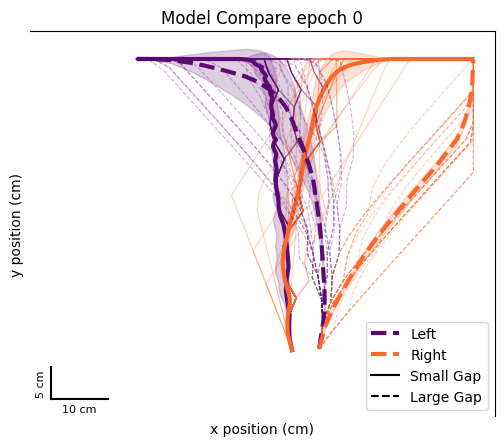

Output()


=== Model Comparison Statistics ===
Small Gap:
  Left trials: Success Rate = 0.95, Avg Reward = -19.00
  Right trials: Success Rate = 1.00, Avg Reward = -7.31
Large Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -5.82
  Right trials: Success Rate = 1.00, Avg Reward = -4.15


Output()

Model saved to ./0630_ablation_vonly_mouse_navigation_modelw13
Running Small Gap trials...
Running Large Gap trials...


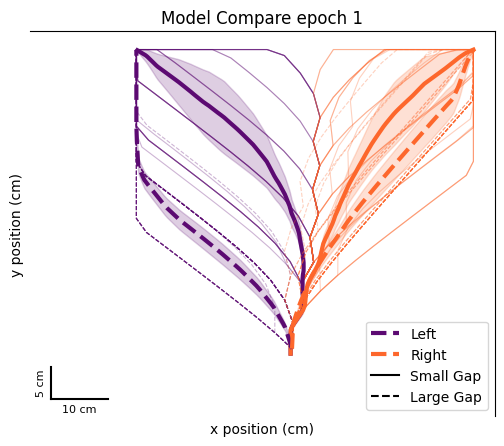

Output()


=== Model Comparison Statistics ===
Small Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -5.70
  Right trials: Success Rate = 1.00, Avg Reward = -5.81
Large Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -5.87
  Right trials: Success Rate = 1.00, Avg Reward = -4.42


Output()

Model saved to ./0630_ablation_vonly_mouse_navigation_modelw13
Running Small Gap trials...
Running Large Gap trials...


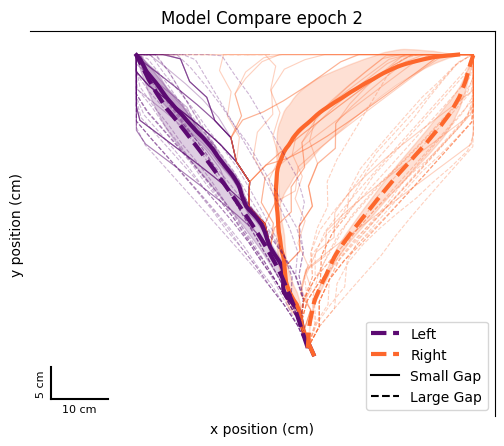

Output()


=== Model Comparison Statistics ===
Small Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -5.02
  Right trials: Success Rate = 0.95, Avg Reward = -7.37
Large Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -4.04
  Right trials: Success Rate = 1.00, Avg Reward = -4.08


Output()

Model saved to ./0630_ablation_vonly_mouse_navigation_modelw13
Running Small Gap trials...
Running Large Gap trials...


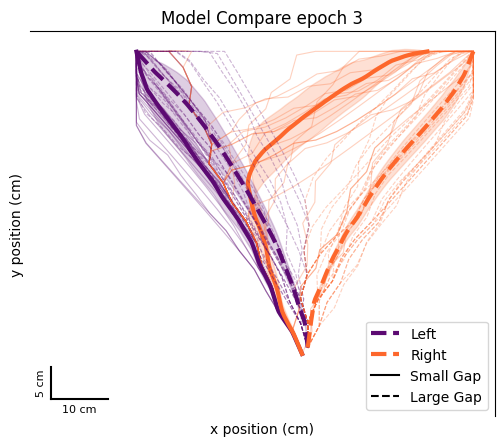

Output()


=== Model Comparison Statistics ===
Small Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -4.56
  Right trials: Success Rate = 0.86, Avg Reward = -7.46
Large Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -3.88
  Right trials: Success Rate = 1.00, Avg Reward = -3.93


Output()

Model saved to ./0630_ablation_vonly_mouse_navigation_modelw13
Running Small Gap trials...
Running Large Gap trials...


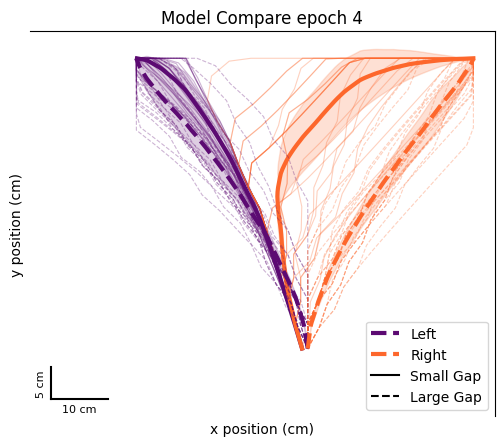

Output()


=== Model Comparison Statistics ===
Small Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -4.42
  Right trials: Success Rate = 1.00, Avg Reward = -6.36
Large Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -4.06
  Right trials: Success Rate = 1.00, Avg Reward = -3.76


Output()

Model saved to ./0630_ablation_vonly_mouse_navigation_modelw13
Running Small Gap trials...
Running Large Gap trials...


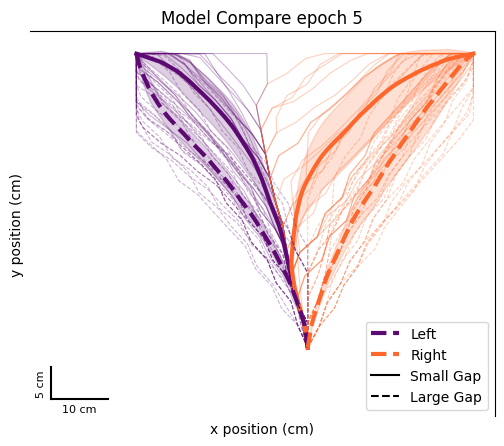

Output()


=== Model Comparison Statistics ===
Small Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -4.73
  Right trials: Success Rate = 1.00, Avg Reward = -5.45
Large Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -4.20
  Right trials: Success Rate = 1.00, Avg Reward = -3.98


Output()

Model saved to ./0630_ablation_vonly_mouse_navigation_modelw13
Running Small Gap trials...
Running Large Gap trials...


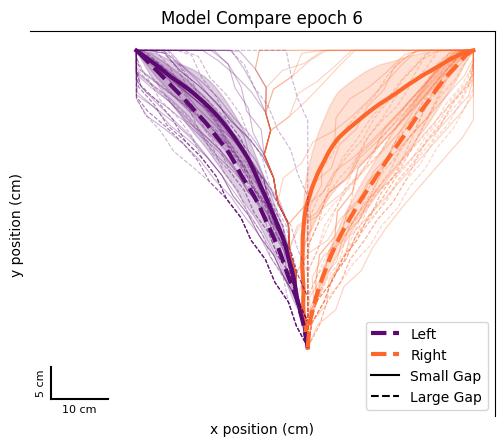

Output()


=== Model Comparison Statistics ===
Small Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -4.77
  Right trials: Success Rate = 1.00, Avg Reward = -5.51
Large Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -4.20
  Right trials: Success Rate = 1.00, Avg Reward = -3.78


Output()

Model saved to ./0630_ablation_vonly_mouse_navigation_modelw13
Running Small Gap trials...
Running Large Gap trials...


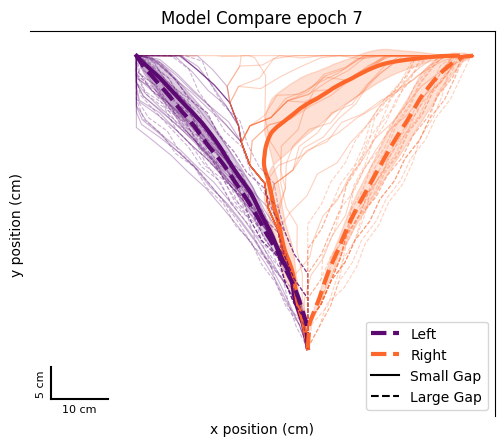

Output()


=== Model Comparison Statistics ===
Small Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -4.77
  Right trials: Success Rate = 0.95, Avg Reward = -7.09
Large Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -3.83
  Right trials: Success Rate = 1.00, Avg Reward = -4.02


Output()

Model saved to ./0630_ablation_vonly_mouse_navigation_modelw13
Running Small Gap trials...
Running Large Gap trials...


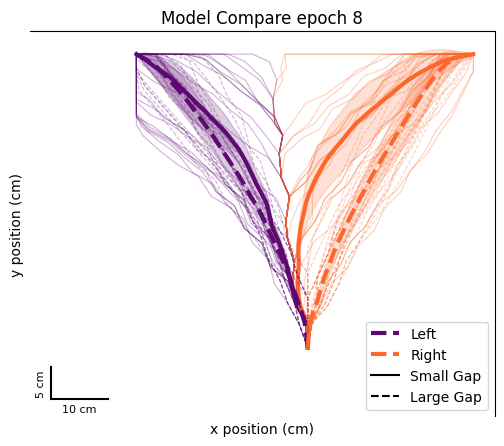

Output()


=== Model Comparison Statistics ===
Small Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -5.31
  Right trials: Success Rate = 1.00, Avg Reward = -5.20
Large Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -3.92
  Right trials: Success Rate = 1.00, Avg Reward = -4.11


Output()

Model saved to ./0630_ablation_vonly_mouse_navigation_modelw13
Running Small Gap trials...
Running Large Gap trials...


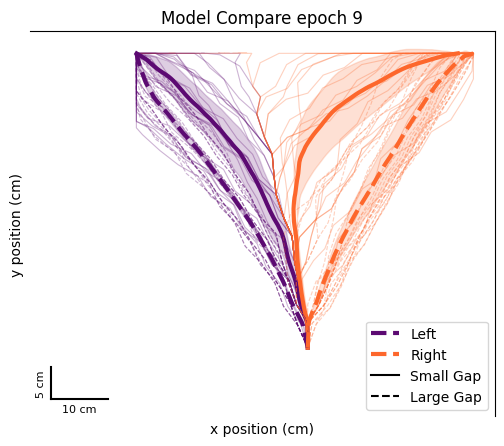

Output()


=== Model Comparison Statistics ===
Small Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -5.02
  Right trials: Success Rate = 0.95, Avg Reward = -6.23
Large Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -3.77
  Right trials: Success Rate = 1.00, Avg Reward = -3.93


Output()

Model saved to ./0630_ablation_vonly_mouse_navigation_modelw13
Running Small Gap trials...
Running Large Gap trials...


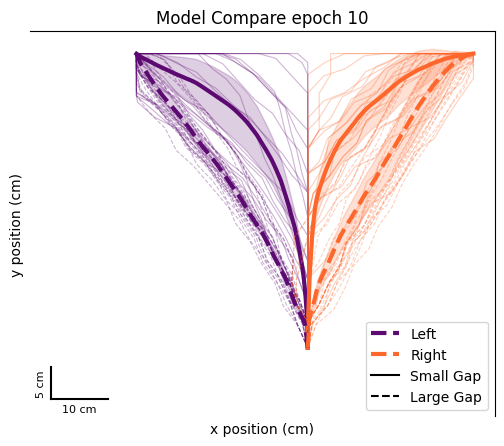

Output()


=== Model Comparison Statistics ===
Small Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -5.16
  Right trials: Success Rate = 1.00, Avg Reward = -5.04
Large Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -3.73
  Right trials: Success Rate = 1.00, Avg Reward = -4.04


Output()

Model saved to ./0630_ablation_vonly_mouse_navigation_modelw13
Running Small Gap trials...
Running Large Gap trials...


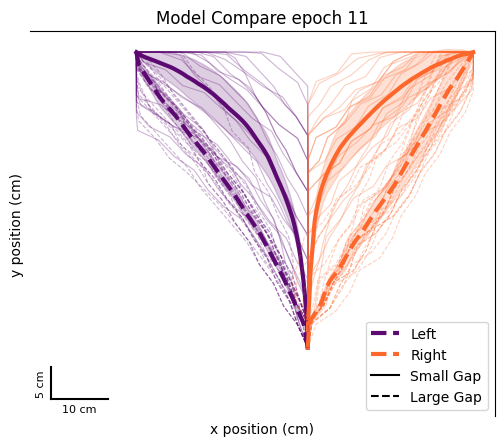

Output()


=== Model Comparison Statistics ===
Small Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -5.24
  Right trials: Success Rate = 1.00, Avg Reward = -4.95
Large Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -3.72
  Right trials: Success Rate = 1.00, Avg Reward = -3.68


Output()

Model saved to ./0630_ablation_vonly_mouse_navigation_modelw13
Running Small Gap trials...
Running Large Gap trials...


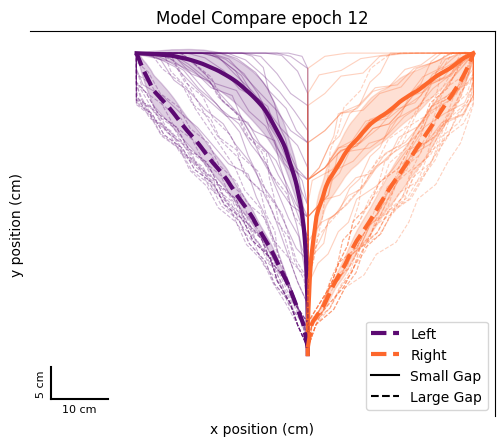

Output()


=== Model Comparison Statistics ===
Small Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -5.27
  Right trials: Success Rate = 1.00, Avg Reward = -4.82
Large Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -4.04
  Right trials: Success Rate = 1.00, Avg Reward = -3.66


Output()

Model saved to ./0630_ablation_vonly_mouse_navigation_modelw13
Running Small Gap trials...
Running Large Gap trials...


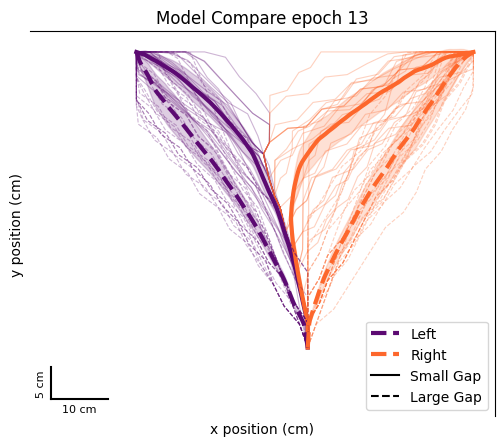

Output()


=== Model Comparison Statistics ===
Small Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -4.58
  Right trials: Success Rate = 1.00, Avg Reward = -5.41
Large Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -3.98
  Right trials: Success Rate = 1.00, Avg Reward = -3.74


Output()

Model saved to ./0630_ablation_vonly_mouse_navigation_modelw13
Running Small Gap trials...
Running Large Gap trials...


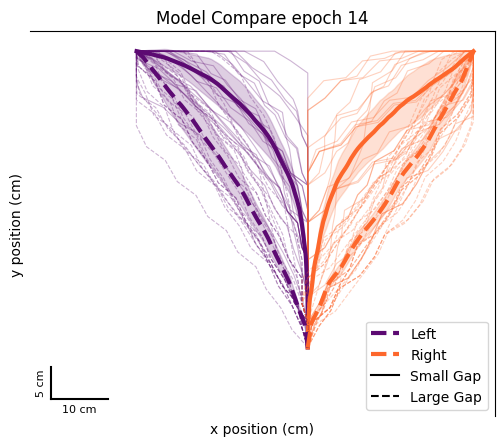


=== Model Comparison Statistics ===
Small Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -4.95
  Right trials: Success Rate = 1.00, Avg Reward = -4.86
Large Gap:
  Left trials: Success Rate = 1.00, Avg Reward = -3.95
  Right trials: Success Rate = 1.00, Avg Reward = -3.65


In [9]:
for epoch in range(15):

    model_small.verbose = 0
    model_small.learn(total_timesteps=20000, progress_bar=True)

    # Save the trained model
    model_path = f"./{note}_mouse_navigation_modelw{smallgap}"
    model_small.save(model_path)


    model_large.verbose = 0
    model_large.learn(total_timesteps=20000, progress_bar=True)

    # Save the trained model
    model_path = f"./{note}_mouse_navigation_modelw{largegap}"
    model_large.save(model_path)
    print(f"Model saved to {model_path}")


    compare_models_noise(
    model_small, model_large, 
    env_small, env_large, 
    info_matrix_small, info_matrix_large, 
    trials_per_condition=22,
    model1_label="Small Gap",
    model2_label="Large Gap",
    colors_choice = ["#5C0A72", "#FD672C"],
    save_path="model_comparison.svg",
    figure_title=f"Model Compare epoch {epoch}"
)